EXPERIMENT 3
POLICY AND VALUE FUNCTION REPRESENTATION USING BELLMAN EQUATIONS

10 SAMPLE DATASET RECORDS


,State,Action,Reward,Next_State,Gamma
0,16,1,-0.51,1,0.896
1,13,3,4.46,15,0.912
2,16,3,3.12,19,0.990
3,14,2,4.41,14,0.934
4,17,2,2.52,20,0.904
5,15,1,3.27,0,0.869
6,18,1,10.00,10,0.962
7,18,3,3.53,11,0.896
8,18,3,-1.75,16,0.935
9,22,1,4.84,15,0.958


Total Dataset Records: 500

DATASET SUMMARY


,Feature,Minimum,Maximum,Mean
0,State,0.00,24.00,11.976
1,Action,0.00,3.00,1.460
2,Reward,-5.00,10.00,2.545
3,Next_State,0.00,24.00,11.998
4,Gamma,0.85,0.99,0.921



DOWNLOAD YOUR COMPLETE DATASET:


...

<IPython.core.display.Javascript object>


POLICY AND VALUE FUNCTION RESULTS


,State,Value V(s),Optimal Action
0,"(0, 0)",3.871,DOWN
1,"(0, 1)",5.412,RIGHT
2,"(0, 2)",7.124,DOWN
3,"(0, 3)",9.027,DOWN
4,"(0, 4)",11.141,DOWN
5,"(1, 0)",5.412,DOWN
6,"(1, 1)",NA,Obstacle
7,"(1, 2)",9.027,DOWN
8,"(1, 3)",11.141,RIGHT
9,"(1, 4)",13.49,DOWN



SUMMARY RESULTS


,Metric,Result
0,Dataset Records,500
1,GMM Components,3
2,Grid Size,5 x 5
3,Total States,25
4,Obstacle States,3
5,Goal State,"(4, 4)"
6,Discount Factor,0.9
7,Convergence Threshold,0.001
8,Iterations,9
9,Maximum Value,19.0


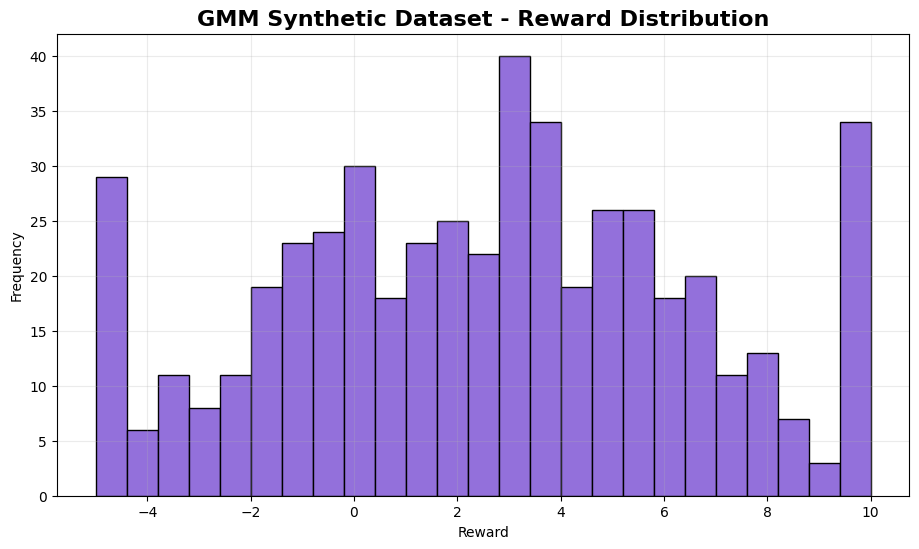

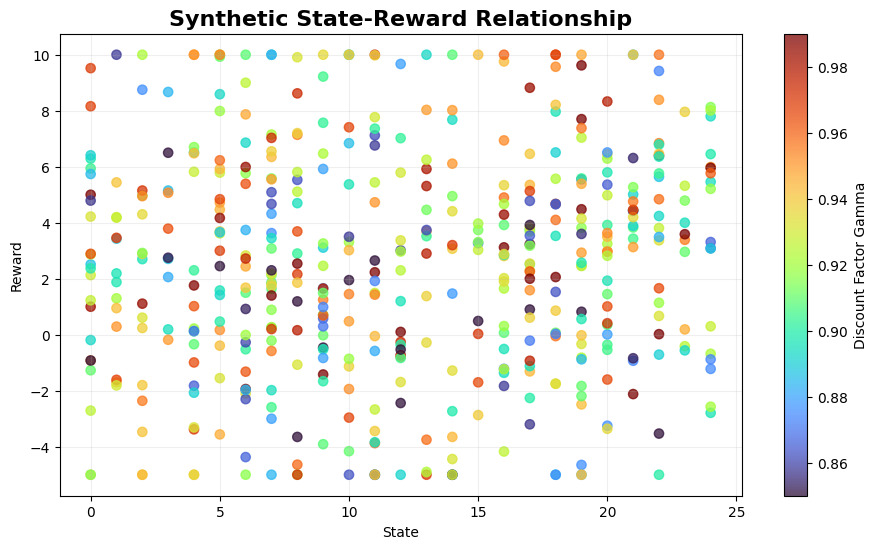

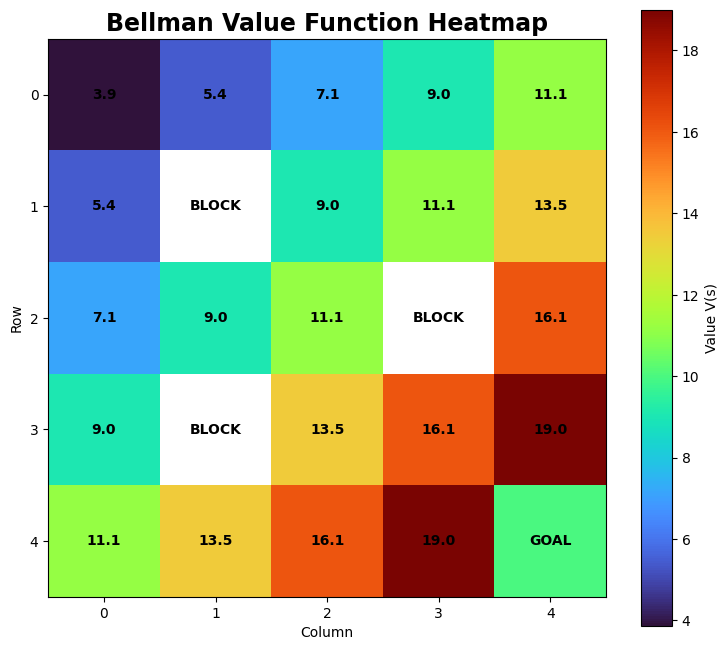

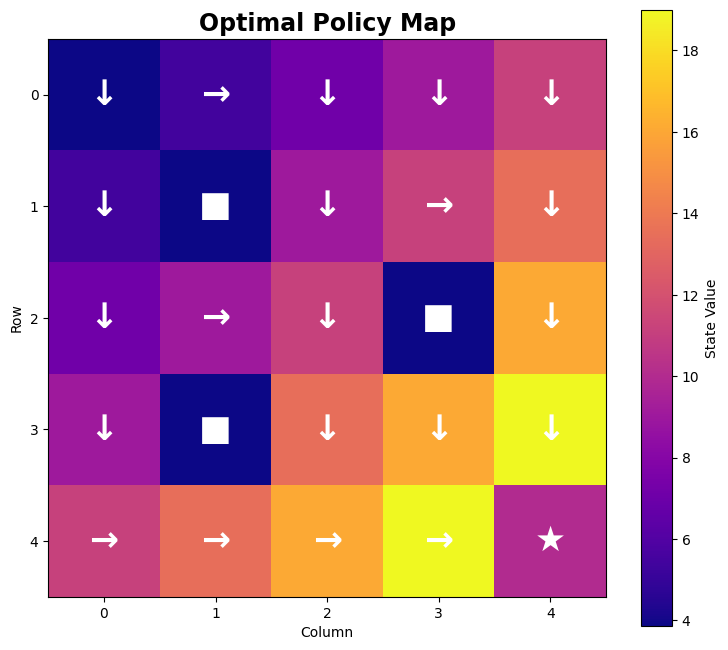

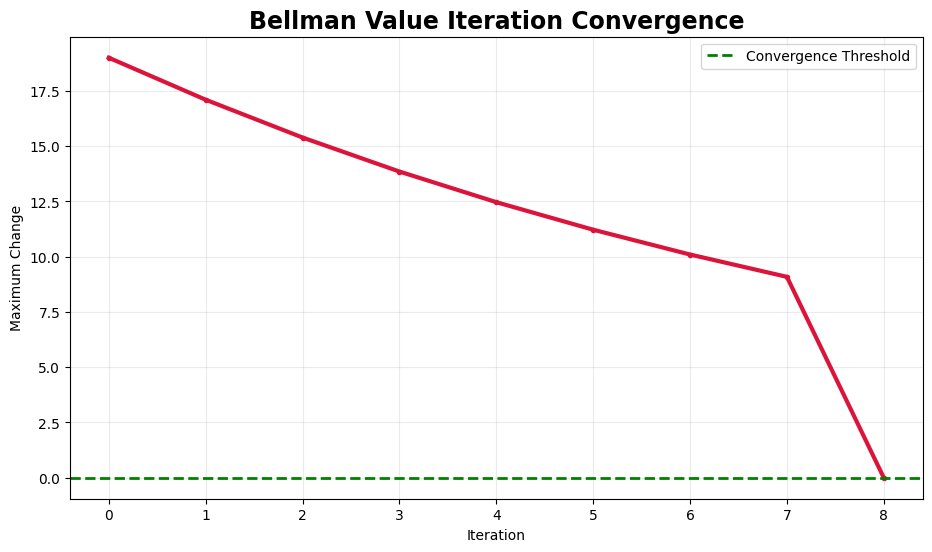


FINAL RESULT

Value Iteration converged after 9 iterations.

Maximum State Value : 19.000
Minimum State Value : 3.871
Average State Value : 11.256

The optimal policy was successfully extracted
using the Bellman optimality equation.

Dataset:
500 synthetic GMM records generated.
10 sample records displayed.
Complete CSV dataset available for download.



In [ ]:
# ==============================================================
# EXPERIMENT 3
# POLICY AND VALUE FUNCTION REPRESENTATION USING BELLMAN EQUATIONS
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from IPython.display import display, FileLink
from google.colab import files

np.random.seed(42)

print("=" * 80)
print("EXPERIMENT 3")
print("POLICY AND VALUE FUNCTION REPRESENTATION USING BELLMAN EQUATIONS")
print("=" * 80)

# ==============================================================
# 1. GMM DATASET GENERATION
# ==============================================================

N = 500

base_data = np.column_stack([
    np.random.uniform(0, 24, N),       # State
    np.random.uniform(0, 3, N),        # Action
    np.random.uniform(-5, 10, N),      # Reward
    np.random.uniform(0, 24, N),       # Next State
    np.random.uniform(0.85, 0.99, N)   # Gamma
])

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(base_data)

generated = gmm.sample(N)[0]

dataset = pd.DataFrame(
    generated,
    columns=[
        "State",
        "Action",
        "Reward",
        "Next_State",
        "Gamma"
    ]
)

dataset["State"] = dataset["State"].clip(0, 24).round().astype(int)
dataset["Action"] = dataset["Action"].clip(0, 3).round().astype(int)
dataset["Reward"] = dataset["Reward"].clip(-5, 10).round(2)
dataset["Next_State"] = dataset["Next_State"].clip(0, 24).round().astype(int)
dataset["Gamma"] = dataset["Gamma"].clip(0.85, 0.99).round(3)

# ==============================================================
# 2. DISPLAY 10 SAMPLE RECORDS
# ==============================================================

print("\n" + "=" * 80)
print("10 SAMPLE DATASET RECORDS")
print("=" * 80)

display(dataset.head(10))

print("Total Dataset Records:", len(dataset))

# ==============================================================
# 3. DATASET SUMMARY
# ==============================================================

print("\n" + "=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

dataset_summary = pd.DataFrame({
    "Feature": dataset.columns,
    "Minimum": [
        dataset[c].min() for c in dataset.columns
    ],
    "Maximum": [
        dataset[c].max() for c in dataset.columns
    ],
    "Mean": [
        round(dataset[c].mean(), 3)
        for c in dataset.columns
    ]
})

display(dataset_summary)

# ==============================================================
# 4. SAVE + DOWNLOAD DATASET
# ==============================================================

filename = "Experiment_3_Bellman_GMM_Dataset.csv"

dataset.to_csv(
    filename,
    index=False
)

print("\nDOWNLOAD YOUR COMPLETE DATASET:")

display(FileLink(filename))

files.download(filename)

# ==============================================================
# 5. GRIDWORLD
# ==============================================================

ROWS = 5
COLS = 5

states = [
    (r, c)
    for r in range(ROWS)
    for c in range(COLS)
]

GOAL = (4, 4)

OBSTACLES = [
    (1, 1),
    (2, 3),
    (3, 1)
]

ACTIONS = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1)
}

ARROWS = {
    "UP": "↑",
    "DOWN": "↓",
    "LEFT": "←",
    "RIGHT": "→"
}

GAMMA = 0.90
THETA = 0.001

# ==============================================================
# 6. TRANSITION FUNCTION
# ==============================================================

def transition(state, action):

    if state == GOAL:
        return state, 0

    dr, dc = ACTIONS[action]

    nr = state[0] + dr
    nc = state[1] + dc

    if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS:
        return state, -2

    next_state = (nr, nc)

    if next_state in OBSTACLES:
        return state, -5

    if next_state == GOAL:
        return next_state, 10

    return next_state, -1

# ==============================================================
# 7. VALUE ITERATION
# ==============================================================

V = {
    s: 0.0
    for s in states
}

for obstacle in OBSTACLES:
    V[obstacle] = np.nan

V[GOAL] = 10

delta_history = []
average_value_history = []

for iteration in range(1, 1001):

    new_V = V.copy()
    delta = 0

    for state in states:

        if state in OBSTACLES or state == GOAL:
            continue

        action_values = []

        for action in ACTIONS:

            next_state, reward = transition(
                state,
                action
            )

            value = (
                reward +
                GAMMA * V[next_state]
            )

            action_values.append(value)

        new_V[state] = max(action_values)

        delta = max(
            delta,
            abs(new_V[state] - V[state])
        )

    V = new_V

    valid_values = [
        V[s]
        for s in states
        if s not in OBSTACLES
    ]

    delta_history.append(delta)
    average_value_history.append(
        np.mean(valid_values)
    )

    if delta < THETA:
        break

# ==============================================================
# 8. OPTIMAL POLICY
# ==============================================================

policy = {}

for state in states:

    if state in OBSTACLES:
        policy[state] = "BLOCK"
        continue

    if state == GOAL:
        policy[state] = "GOAL"
        continue

    best_action = None
    best_value = -np.inf

    for action in ACTIONS:

        next_state, reward = transition(
            state,
            action
        )

        q_value = (
            reward +
            GAMMA * V[next_state]
        )

        if q_value > best_value:
            best_value = q_value
            best_action = action

    policy[state] = best_action

# ==============================================================
# 9. VALUE MATRIX
# ==============================================================

value_matrix = np.zeros(
    (ROWS, COLS)
)

for r in range(ROWS):
    for c in range(COLS):

        if (r, c) in OBSTACLES:
            value_matrix[r, c] = np.nan
        else:
            value_matrix[r, c] = V[(r, c)]

# ==============================================================
# 10. POLICY RESULT TABLE
# ==============================================================

policy_table = []

for state in states:

    if state in OBSTACLES:
        action = "Obstacle"
    elif state == GOAL:
        action = "Goal"
    else:
        action = policy[state]

    policy_table.append([
        state,
        round(V[state], 3) if not np.isnan(V[state]) else "NA",
        action
    ])

policy_df = pd.DataFrame(
    policy_table,
    columns=[
        "State",
        "Value V(s)",
        "Optimal Action"
    ]
)

print("\n" + "=" * 80)
print("POLICY AND VALUE FUNCTION RESULTS")
print("=" * 80)

display(policy_df)

# ==============================================================
# 11. SUMMARY TABLE
# ==============================================================

normal_values = [
    V[s]
    for s in states
    if s not in OBSTACLES
    and s != GOAL
]

summary = pd.DataFrame({
    "Metric": [
        "Dataset Records",
        "GMM Components",
        "Grid Size",
        "Total States",
        "Obstacle States",
        "Goal State",
        "Discount Factor",
        "Convergence Threshold",
        "Iterations",
        "Maximum Value",
        "Minimum Value",
        "Average Value",
        "Goal Value"
    ],

    "Result": [
        len(dataset),
        3,
        "5 x 5",
        len(states),
        len(OBSTACLES),
        str(GOAL),
        GAMMA,
        THETA,
        iteration,
        round(max(normal_values), 3),
        round(min(normal_values), 3),
        round(np.mean(normal_values), 3),
        V[GOAL]
    ]
})

print("\n" + "=" * 80)
print("SUMMARY RESULTS")
print("=" * 80)

display(summary)

# ==============================================================
# 12. VISUALIZATION 1
# GMM FEATURE DISTRIBUTION
# ==============================================================

plt.figure(figsize=(11, 6))

plt.hist(
    dataset["Reward"],
    bins=25,
    color="mediumpurple",
    edgecolor="black"
)

plt.title(
    "GMM Synthetic Dataset - Reward Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 13. VISUALIZATION 2
# STATE VS REWARD
# ==============================================================

plt.figure(figsize=(11, 6))

scatter = plt.scatter(
    dataset["State"],
    dataset["Reward"],
    c=dataset["Gamma"],
    cmap="turbo",
    s=45,
    alpha=0.75
)

plt.colorbar(
    scatter,
    label="Discount Factor Gamma"
)

plt.title(
    "Synthetic State-Reward Relationship",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Reward")
plt.grid(alpha=0.2)

plt.show()

# ==============================================================
# 14. VISUALIZATION 3
# VALUE FUNCTION HEATMAP
# ==============================================================

plt.figure(figsize=(9, 8))

plt.imshow(
    value_matrix,
    cmap="turbo"
)

plt.colorbar(
    label="Value V(s)"
)

for r in range(ROWS):
    for c in range(COLS):

        state = (r, c)

        if state in OBSTACLES:
            text = "BLOCK"
        elif state == GOAL:
            text = "GOAL"
        else:
            text = f"{V[state]:.1f}"

        plt.text(
            c,
            r,
            text,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

plt.title(
    "Bellman Value Function Heatmap",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

# ==============================================================
# 15. VISUALIZATION 4
# OPTIMAL POLICY MAP
# ==============================================================

plt.figure(figsize=(9, 8))

plt.imshow(
    np.nan_to_num(
        value_matrix,
        nan=np.nanmin(value_matrix)
    ),
    cmap="plasma"
)

plt.colorbar(
    label="State Value"
)

for r in range(ROWS):
    for c in range(COLS):

        state = (r, c)

        if state in OBSTACLES:
            text = "■"
        elif state == GOAL:
            text = "★"
        else:
            text = ARROWS[policy[state]]

        plt.text(
            c,
            r,
            text,
            ha="center",
            va="center",
            fontsize=25,
            fontweight="bold",
            color="white"
        )

plt.title(
    "Optimal Policy Map",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

# ==============================================================
# 16. VISUALIZATION 5
# BELLMAN CONVERGENCE
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    delta_history,
    color="crimson",
    linewidth=3,
    marker="o",
    markersize=3
)

plt.axhline(
    THETA,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Convergence Threshold"
)

plt.title(
    "Bellman Value Iteration Convergence",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Iteration")
plt.ylabel("Maximum Change")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 17. FINAL RESULT
# ==============================================================

print("\n" + "=" * 80)
print("FINAL RESULT")
print("=" * 80)

print(
    f"""
Value Iteration converged after {iteration} iterations.

Maximum State Value : {max(normal_values):.3f}
Minimum State Value : {min(normal_values):.3f}
Average State Value : {np.mean(normal_values):.3f}

The optimal policy was successfully extracted
using the Bellman optimality equation.

Dataset:
500 synthetic GMM records generated.
10 sample records displayed.
Complete CSV dataset available for download.
"""
)